# Bank Transaction Analysis
### Extended with: Spending Patterns | Cohort Analysis | High-Value Customers | Retention & Targeting

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [146]:
# Load Data
customers = pd.read_csv("customers.csv")
accounts = pd.read_csv("accounts.csv")
transactions = pd.read_csv("transactions.csv")

In [147]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   customer_id   200 non-null    object
 1   name          200 non-null    object
 2   age           200 non-null    int64 
 3   city          200 non-null    object
 4   account_type  200 non-null    object
 5   join_date     200 non-null    object
dtypes: int64(1), object(5)
memory usage: 9.5+ KB


In [148]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  200 non-null    object
 1   balance      200 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.3+ KB


In [149]:
# Check data type
transactions.dtypes

transaction_id    object
customer_id       object
date              object
amount             int64
type              object
merchant          object
dtype: object

In [150]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  5000 non-null   object
 1   customer_id     5000 non-null   object
 2   date            5000 non-null   object
 3   amount          5000 non-null   int64 
 4   type            5000 non-null   object
 5   merchant        5000 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


In [151]:
# Convert date
transactions['date'] = pd.to_datetime(transactions['date'])

In [152]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  5000 non-null   object        
 1   customer_id     5000 non-null   object        
 2   date            5000 non-null   datetime64[ns]
 3   amount          5000 non-null   int64         
 4   type            5000 non-null   object        
 5   merchant        5000 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 234.5+ KB


### SECTION 1 — EDA & Business Insights

In [153]:
# Merge Data
df = transactions.merge(customers, on="customer_id")
df = df.merge(accounts, on="customer_id")


In [154]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (5000, 12)
  transaction_id customer_id       date  amount    type        merchant  \
0         T00001       C0117 2023-01-29   72027  Credit          Zomato   
1         T00002       C0176 2024-07-20   10348   Debit          Swiggy   
2         T00003       C0030 2024-10-20   30541  Credit   Electric Bill   
3         T00004       C0195 2024-11-15   19046   Debit  ATM Withdrawal   
4         T00005       C0132 2024-07-29   35924  Credit  ATM Withdrawal   

           name  age       city account_type   join_date  balance  
0  Customer_117   23       Pune      Current  2019-12-30   102793  
1  Customer_176   52  Hyderabad      Savings  2022-04-18    29077  
2   Customer_30   32       Pune      Savings  2020-02-25    71036  
3  Customer_195   31     Mumbai      Current  2021-04-13   179210  
4  Customer_132   41    Chennai      Current  2018-10-18    35432  


In [155]:
# Feature Engineering
df['month_num'] = df['date'].dt.month
df['month'] = df['date'].dt.strftime('%b')

print(df.head())

  transaction_id customer_id       date  amount    type        merchant  \
0         T00001       C0117 2023-01-29   72027  Credit          Zomato   
1         T00002       C0176 2024-07-20   10348   Debit          Swiggy   
2         T00003       C0030 2024-10-20   30541  Credit   Electric Bill   
3         T00004       C0195 2024-11-15   19046   Debit  ATM Withdrawal   
4         T00005       C0132 2024-07-29   35924  Credit  ATM Withdrawal   

           name  age       city account_type   join_date  balance  month_num  \
0  Customer_117   23       Pune      Current  2019-12-30   102793          1   
1  Customer_176   52  Hyderabad      Savings  2022-04-18    29077          7   
2   Customer_30   32       Pune      Savings  2020-02-25    71036         10   
3  Customer_195   31     Mumbai      Current  2021-04-13   179210         11   
4  Customer_132   41    Chennai      Current  2018-10-18    35432          7   

  month  
0   Jan  
1   Jul  
2   Oct  
3   Nov  
4   Jul  


In [156]:
# --------------------------
# Top Customers by Spending
# --------------------------
top_customers = df.groupby("customer_id")["amount"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Customers by Transaction Amount")
print(top_customers)


Top 10 Customers by Transaction Amount
customer_id
C0059    1173597
C0159    1161486
C0103    1144473
C0110    1120675
C0084    1073124
C0034    1052404
C0006    1045720
C0063    1003177
C0087     999992
C0053     991842
Name: amount, dtype: int64


In [157]:
# --------------------------
# City Wise Revenue
# --------------------------
city_revenue = df.groupby("city")["amount"].sum().sort_values(ascending=False) #desc order
print("\nCity Wise Revenue")
print(city_revenue)



City Wise Revenue
city
Delhi        27226106
Pune         25770528
Hyderabad    19795229
Mumbai       19370882
Bangalore    19076107
Chennai      18890733
Name: amount, dtype: int64


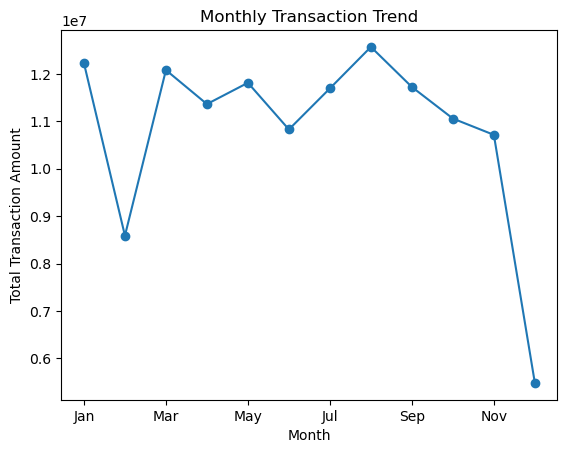

In [158]:
# --------------------------
# Monthly Transaction Trend
# --------------------------

monthly_trend = df.groupby(['month_num', 'month'])['amount'].sum().reset_index()
monthly_trend = monthly_trend.sort_values('month_num')
month_trend = monthly_trend.sort_values('amount',ascending=False)
# print("\nMonths Generating Highest Revenue")
# print(month_trend)
# print("\nMonthly Revenue Performance")
# print(monthly_trend)

plt.figure()
monthly_trend.set_index('month')['amount'].plot(kind='line', marker='o')
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Total Transaction Amount")
plt.show()


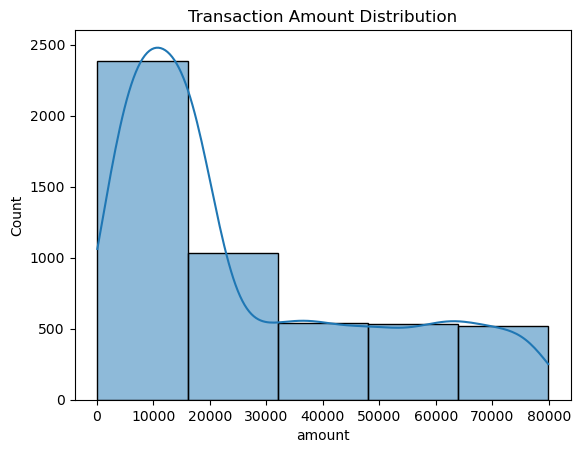

In [159]:
# --------------------------
# Transaction Distribution
# --------------------------
plt.figure()
sns.histplot(df["amount"], bins=5, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()


In [160]:
# --------------------------
# Simple Fraud Detection
# --------------------------
fraud = df[df["amount"] > 100000]

print("\nPotential Fraud Transactions:")
print(fraud.head())



Potential Fraud Transactions:
Empty DataFrame
Columns: [transaction_id, customer_id, date, amount, type, merchant, name, age, city, account_type, join_date, balance, month_num, month]
Index: []


---
## SECTION 2 — Spending Patterns & User Behavior

Top 10 Merchants by Total Spend:
merchant
Salary            17589256
Electric Bill     17098458
Rent              16528471
ATM Withdrawal    16255273
Swiggy            16048301
Amazon            15656968
Flipkart          15574919
Zomato            15377939
Name: amount, dtype: int64


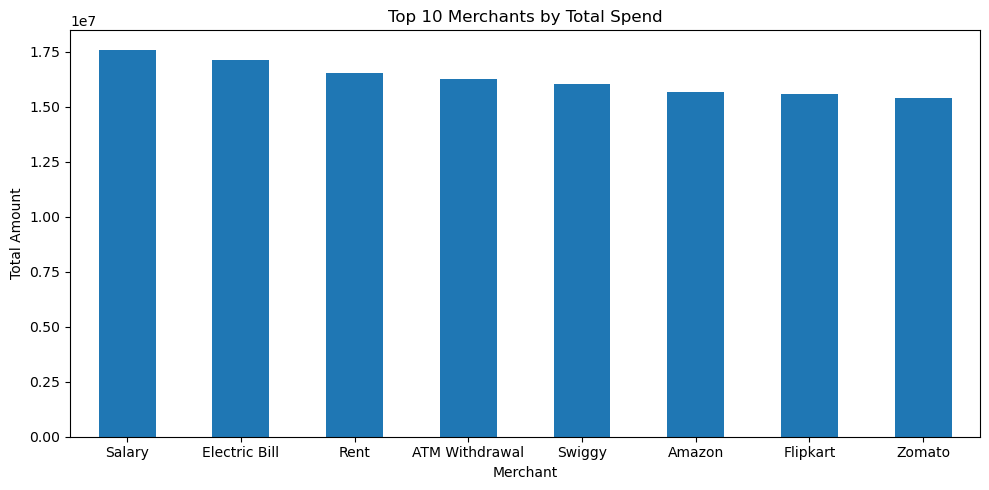

In [161]:
# --------------------------
# Spending by Merchant (Top 10)
# --------------------------
merchant_spend = df.groupby('merchant')['amount'].sum().sort_values(ascending=False).head(10)
print("Top 10 Merchants by Total Spend:")
print(merchant_spend)

plt.figure(figsize=(10, 5))
merchant_spend.plot(kind='bar')
plt.title("Top 10 Merchants by Total Spend")
plt.xlabel("Merchant")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Credit vs Debit Total Spend:
type
Credit    105388745
Debit      24740840
Name: amount, dtype: int64


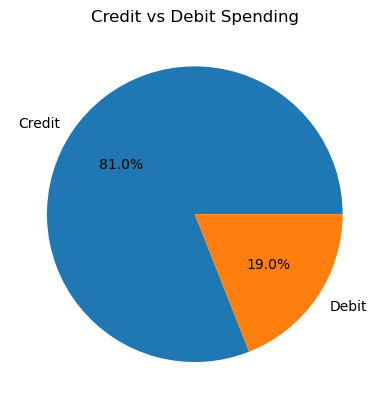

In [162]:
# --------------------------
# Credit vs Debit Spending
# --------------------------
type_spend = df.groupby('type')['amount'].sum()
print("\nCredit vs Debit Total Spend:")
print(type_spend)

plt.figure()
type_spend.plot(kind='pie', autopct='%1.1f%%')
plt.title("Credit vs Debit Spending")
plt.ylabel("")
plt.show()


Spending by Account Type:
              total_spend     avg_spend  txn_count
account_type                                      
Current          61738717  25649.653926       2407
Savings          68390868  26375.190127       2593


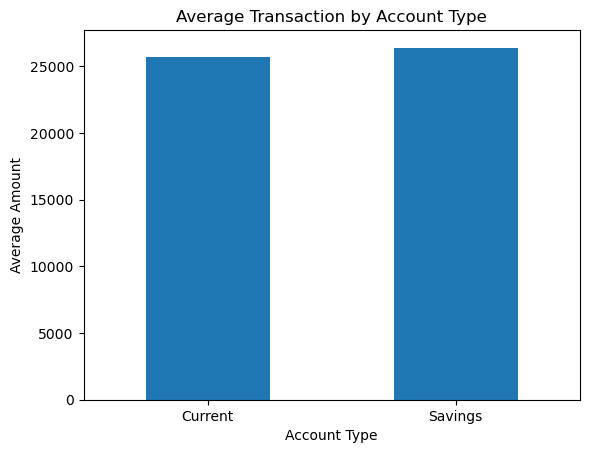

In [163]:
# --------------------------
# Spending by Account Type
# --------------------------
account_spend = df.groupby('account_type')['amount'].agg(['sum', 'mean', 'count'])
account_spend.columns = ['total_spend', 'avg_spend', 'txn_count']  #Reanme the columns
print("\nSpending by Account Type:")
print(account_spend)

plt.figure()
account_spend['avg_spend'].plot(kind='bar')
plt.title("Average Transaction by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Average Amount")
plt.xticks(rotation=0)
plt.show()

C:\Users\amar2\AppData\Local\Temp\ipykernel_44292\2115556625.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spend = df.groupby('age_group')['amount'].sum().sort_index()



Spending by Age Group:
age_group
<25       9579988
25-35    29175420
35-45    26625233
45-60    48862232
60+      15886712
Name: amount, dtype: int64


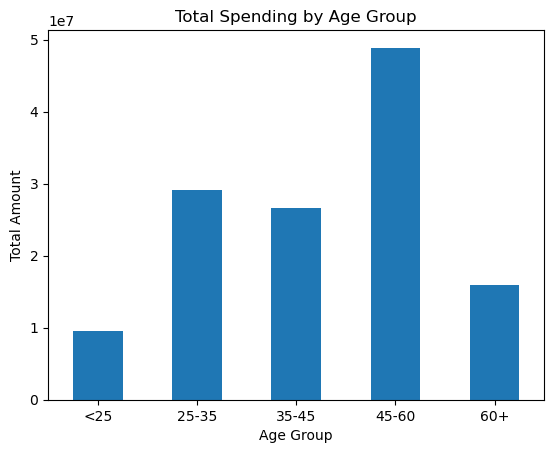

In [215]:
# --------------------------
# Spending by Age Group
# --------------------------
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 60, 100],
                         labels=['<25', '25-35', '35-45', '45-60', '60+'])

age_spend = df.groupby('age_group')['amount'].sum().sort_index()
print("\nSpending by Age Group:")
print(age_spend)

plt.figure()
age_spend.plot(kind='bar')
plt.title("Total Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)
plt.show()


Spending by Day of Week:
day_of_week
Monday       20174261
Tuesday      18742523
Wednesday    17229145
Thursday     18556419
Friday       17925479
Saturday     17960299
Sunday       19541459
Name: amount, dtype: int64


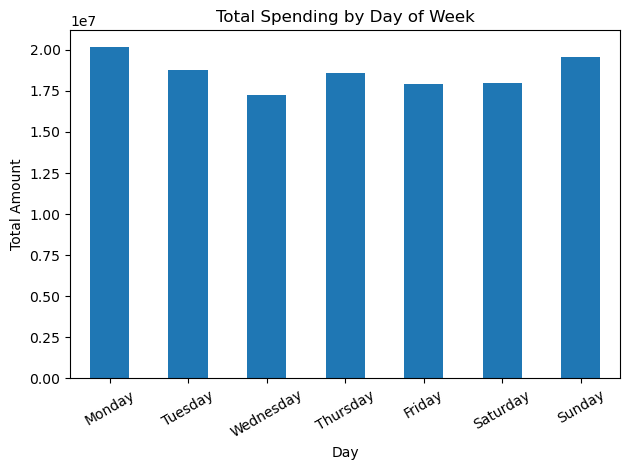

In [165]:
# --------------------------
# Day of Week Spending Pattern
# --------------------------
df['day_of_week'] = df['date'].dt.day_name()

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_spend = df.groupby('day_of_week')['amount'].sum().reindex(dow_order)
print("\nSpending by Day of Week:")
print(dow_spend)

plt.figure()
dow_spend.plot(kind='bar')
plt.title("Total Spending by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## NEW SECTION 3 — Cohort-Style & Time-Based Analysis

In [166]:
# --------------------------
# Cohort Analysis
# Cohort = the month a customer made their FIRST transaction
# --------------------------

# Step 1: Find each customer's first transaction month
# Step 1: Add year_month to transactions (use original, not df)
transactions['date'] = pd.to_datetime(transactions['date'])
transactions['year_month'] = transactions['date'].dt.to_period('M')


# Step 2: Find each customer's first transaction month
first_txn = transactions.groupby('customer_id')['year_month'].min().reset_index()
first_txn.columns = ['customer_id', 'cohort_month']

# Step 3: Merge cohort month into transactions
txn_cohort = transactions.merge(first_txn, on='customer_id')

# Step 4: Calculate how many months after first transaction each txn happened
txn_cohort['period_number'] = (txn_cohort['year_month'] - txn_cohort['cohort_month']).apply(lambda x: x.n)


# Step 5: Count unique customers per cohort and period
cohort_data = txn_cohort.groupby(['cohort_month', 'period_number'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='period_number', values='customer_id')

# Step 6: Calculate retention % (relative to month 0)
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

print("Cohort Retention Table (% of customers still active):")
print(retention.round(1))

Cohort Retention Table (% of customers still active):
period_number     0      1      2      3      4      5      6      7      8   \
cohort_month                                                                   
2023-01        100.0   58.0   67.1   64.3   65.0   69.9   66.4   67.1   60.1   
2023-02        100.0   66.7   62.5   58.3   58.3   66.7   50.0   75.0   62.5   
2023-03        100.0   60.9   60.9   65.2   56.5   65.2   69.6   65.2   60.9   
2023-04        100.0   83.3   66.7   83.3   83.3   50.0  100.0   66.7  100.0   
2023-06        100.0  100.0  100.0  100.0  100.0  100.0   50.0   50.0   50.0   
2023-07        100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0   
2023-08        100.0    NaN  100.0    NaN    NaN  100.0    NaN    NaN    NaN   

period_number    9   ...    14     15     16    17    18    19    20    21  \
cohort_month         ...                                                     
2023-01        68.5  ...  71.3   65.7   73.4  67.1  68.5  65.7  69.2 

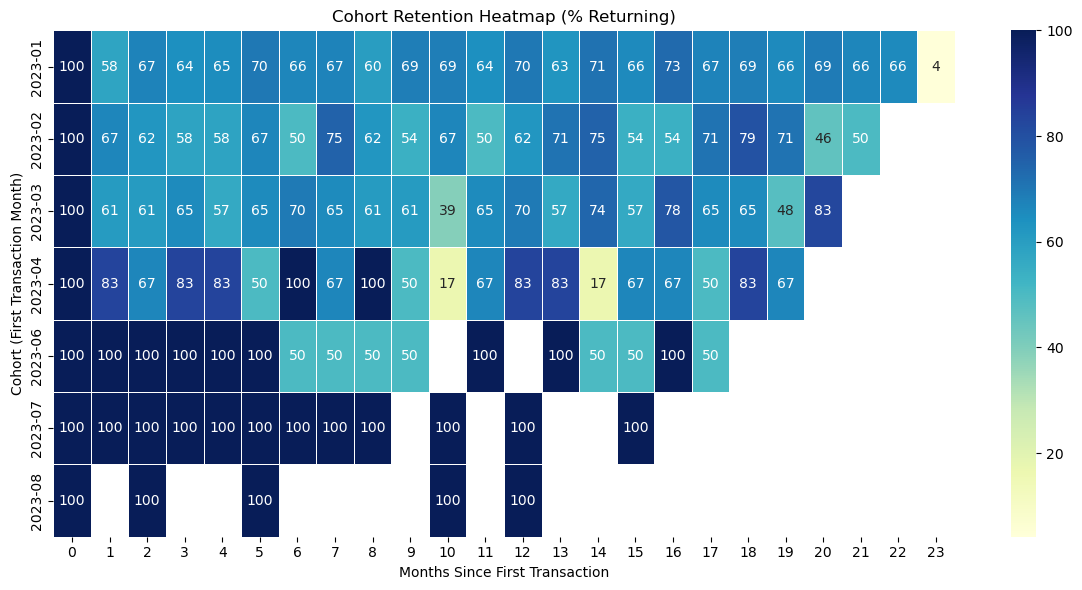

In [167]:
# --------------------------
# Cohort Retention Heatmap
# --------------------------
plt.figure(figsize=(12, 6))
sns.heatmap(retention.astype(float), annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title("Cohort Retention Heatmap (% Returning)")
plt.xlabel("Months Since First Transaction")
plt.ylabel("Cohort (First Transaction Month)")
plt.tight_layout()
plt.show()


Monthly Active Customers:
   month  active_customers
4    Jan               170
3    Feb               162
7    Mar               182
0    Apr               174
8    May               184
6    Jun               174
5    Jul               180
1    Aug               185
11   Sep               178
10   Oct               173
9    Nov               177
2    Dec               132


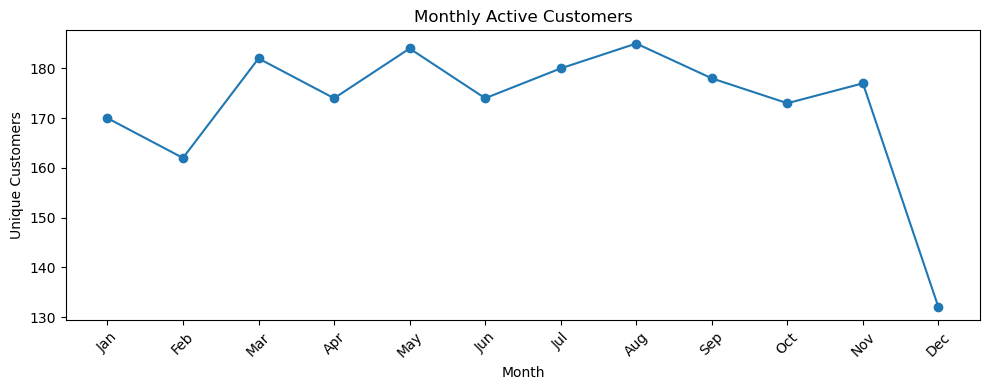

In [168]:
# --------------------------
# Monthly Active Customers (Engagement Trend)
# --------------------------
# print(df.columns) #To see al columns REMEMBER
# df['year_month'] = pd.to_datetime(df['transaction_date']).dt.to_period('M')  --To create new col if month not exists*
mau = df.groupby('month')['customer_id'].nunique().reset_index()

mau.columns = ['month', 'active_customers'] #rename
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
mau['month'] = pd.Categorical(mau['month'], categories=month_order, ordered=True)   # to sort month 
mau = mau.sort_values('month')

# mau['month'] = mau['month'].astype(str)     --for * , to treat date objects as str for ploting.

print("\nMonthly Active Customers:")
print(mau)

plt.figure(figsize=(10, 4))
plt.plot(mau['month'], mau['active_customers'], marker='o')
plt.title("Monthly Active Customers")
plt.xlabel("Month")
plt.ylabel("Unique Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Monthly Revenue:
   month  total_revenue
4    Jan       12224346
3    Feb        8589415
7    Mar       12078874
0    Apr       11361881
8    May       11810949
6    Jun       10827093
5    Jul       11692328
1    Aug       12566622
11   Sep       11722327
10   Oct       11057086
9    Nov       10713676
2    Dec        5484988


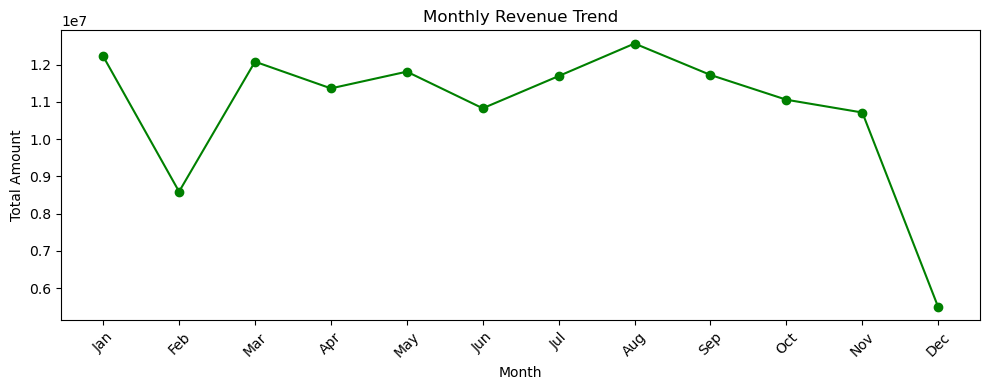

In [169]:
# --------------------------
# Monthly Revenue Trend (Time-Based)
# --------------------------
monthly_rev = df.groupby('month')['amount'].sum().reset_index()
# monthly_rev=monthly_rev.sort_values('amount') --if amount you want
monthly_rev.columns = ['month', 'total_revenue']
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_rev['month'] = pd.Categorical(monthly_rev['month'], categories=month_order, ordered=True)   # to sort month 
monthly_rev = monthly_rev.sort_values('month')

monthly_rev['month'] = monthly_rev['month'].astype(str)

print("\nMonthly Revenue:")
print(monthly_rev)

plt.figure(figsize=(10, 4))
plt.plot(monthly_rev['month'], monthly_rev['total_revenue'], marker='o', color='green')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## NEW SECTION 4 — High-Value Customers (RFM Analysis)

In [186]:
# --------------------------
# RFM Analysis
# R = Recency (days since last transaction)
# F = Frequency (number of transactions)
# M = Monetary (total spend)
# --------------------------

# Set snapshot date as the day after the last transaction
snapshot_date = df['date'].max() + pd.Timedelta(days=1)   #---pd.Timestamp('today') for real data

rfm = df.groupby('customer_id').agg(
    recency   = ('date', lambda x: (snapshot_date - x.max()).days),
   
    frequency = ('transaction_id', 'count'),
    monetary  = ('amount', 'sum')
).reset_index()

print("RFM Table (first 10 rows):")
print(rfm.head(10))

RFM Table (first 10 rows):
  customer_id  recency  frequency  monetary
0       C0001       57         21    678463
1       C0002       12         22    606327
2       C0003        6         36    785324
3       C0004       17         18    403074
4       C0005       34         30    779244
5       C0006       48         24   1045720
6       C0007       11         26    619886
7       C0008        4         36    964444
8       C0009        5         15    505416
9       C0010       14         24    729737


In [190]:
# --------------------------
# Score each R, F, M on a 1–3 scale
# --------------------------

# Recency: lower is better → score 3 for lowest recency
rfm['R_score'] = pd.qcut(rfm['recency'], q=3, labels=[3, 2, 1]).astype(int)

# Frequency: higher is better → score 3 for highest frequency
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=3, labels=[1, 2, 3]).astype(int)

# Monetary: higher is better → score 3 for highest spend
rfm['M_score'] = pd.qcut(rfm['monetary'], q=3, labels=[1, 2, 3]).astype(int)

rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print("RFM Scores:")
print(rfm.head(10))

RFM Scores:
  customer_id  recency  frequency  monetary  R_score  F_score  M_score  \
0       C0001       57         21    678463        1        1        2   
1       C0002       12         22    606327        3        1        2   
2       C0003        6         36    785324        3        3        3   
3       C0004       17         18    403074        2        1        1   
4       C0005       34         30    779244        1        3        3   
5       C0006       48         24   1045720        1        2        3   
6       C0007       11         26    619886        3        2        2   
7       C0008        4         36    964444        3        3        3   
8       C0009        5         15    505416        3        1        1   
9       C0010       14         24    729737        2        2        3   

   RFM_total  
0          4  
1          6  
2          9  
3          4  
4          7  
5          6  
6          7  
7          9  
8          5  
9          7  


In [195]:
# --------------------------
# Label customers into segments
# --------------------------

def label_segment(score):
    if score >= 8:
        return 'High Value'
    elif score >= 5:
        return 'Mid Value'
    else:
        return 'Low Value'

rfm['segment'] = rfm['RFM_total'].apply(label_segment)

print("\nCustomer Segment Counts:")
# print(rfm.head(10))
print(rfm['segment'].value_counts())


Customer Segment Counts:
segment
Mid Value     95
Low Value     53
High Value    52
Name: count, dtype: int64


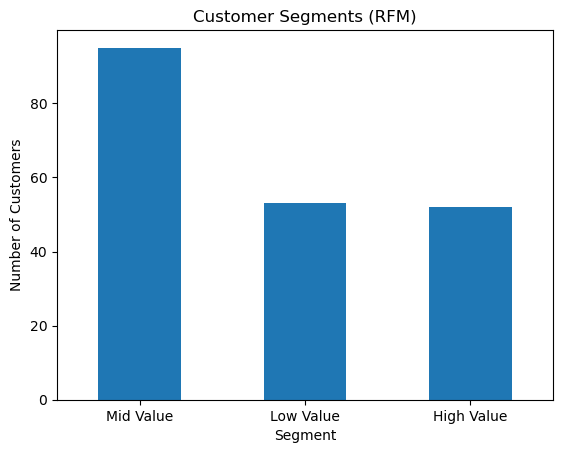

In [173]:
# --------------------------
# Plot RFM Segments
# --------------------------
seg_counts = rfm['segment'].value_counts()

plt.figure()
seg_counts.plot(kind='bar')
plt.title("Customer Segments (RFM)")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

---
## NEW SECTION 5 — Retention & Campaign Targeting Opportunities

In [197]:
# --------------------------
# Churn Detection
# Mark customers inactive if last transaction > 90 days ago
# --------------------------
CHURN_DAYS = 90

rfm['churned'] = rfm['recency'] > CHURN_DAYS

churn_count = rfm['churned'].value_counts()
print(f"Churn threshold: {CHURN_DAYS} days")
print(f"Active customers: {churn_count.get(False, 0)}")
print(f"Churned customers: {churn_count.get(True, 0)}")
print(f"Churn rate: {rfm['churned'].mean() * 100:.1f}%")

Churn threshold: 90 days
Active customers: 192
Churned customers: 8
Churn rate: 4.0%


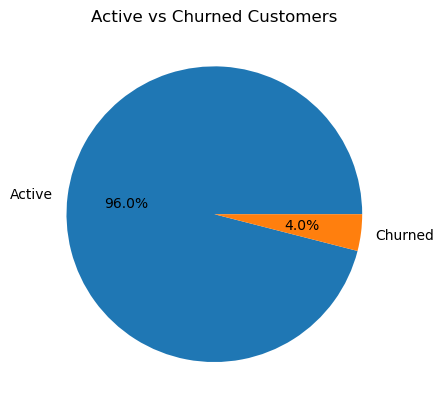

In [198]:
# # --------------------------
# # Plot Churn vs Active
# # --------------------------
labels = ['Active', 'Churned']
values = [churn_count.get(False, 0), churn_count.get(True, 0)]

plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Active vs Churned Customers")
plt.show()


Retention Rate by City:
           churned  total  retention_rate_%
city                                       
Pune             0     40             100.0
Bangalore        1     30              96.7
Chennai          1     30              96.7
Delhi            2     39              94.9
Mumbai           2     31              93.5
Hyderabad        2     30              93.3


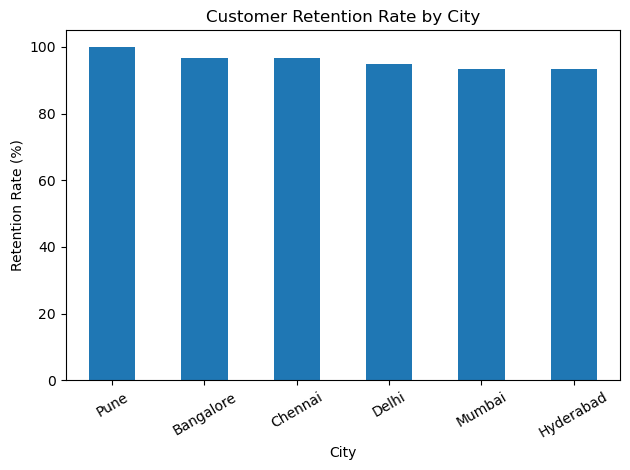

In [205]:
# --------------------------
# Retention by City
# --------------------------
rfm_city = rfm.merge(customers[['customer_id', 'city']], on='customer_id')

city_churn = rfm_city.groupby('city')['churned'].agg(['sum', 'count'])
city_churn.columns = ['churned', 'total']
city_churn['retention_rate_%'] = ((city_churn['total'] - city_churn['churned']) / city_churn['total'] * 100).round(1)
city_churn = city_churn.sort_values('retention_rate_%', ascending=False)

print("\nRetention Rate by City:")
print(city_churn)

plt.figure()
city_churn['retention_rate_%'].plot(kind='bar')
plt.title("Customer Retention Rate by City")
plt.xlabel("City")
plt.ylabel("Retention Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [208]:
# # --------------------------
# # Campaign Targeting Lists
# # --------------------------

# # 1. Win-Back Campaign: churned customers who were previously mid/high value
winback = rfm[(rfm['churned'] == True) & (rfm['segment'].isin(['High Value', 'Mid Value']))]
print(f"Win-Back Campaign target: {len(winback)} customers")
print(winback[['customer_id', 'recency', 'frequency', 'monetary', 'segment']].head())

print()

# 2. Loyalty Reward: active High-Value customers
loyalty = rfm[(rfm['churned'] == False) & (rfm['segment'] == 'High Value')]
print(f"Loyalty Reward Campaign target: {len(loyalty)} customers")
print(loyalty[['customer_id', 'recency', 'frequency', 'monetary']].head())

print()

# 3. Upsell Campaign: active Mid-Value customers (upgrade potential)
upsell = rfm[(rfm['churned'] == False) & (rfm['segment'] == 'Mid Value')]
print(f"Upsell Campaign target: {len(upsell)} customers")
print(upsell[['customer_id', 'recency', 'frequency', 'monetary']].head())
print()

Win-Back Campaign target: 1 customers
   customer_id  recency  frequency  monetary    segment
78       C0079      147         22    754371  Mid Value

Loyalty Reward Campaign target: 52 customers
   customer_id  recency  frequency  monetary
2        C0003        6         36    785324
7        C0008        4         36    964444
13       C0014       21         29    828764
17       C0018        4         25    904258
25       C0026       18         32    965245

Upsell Campaign target: 94 customers
  customer_id  recency  frequency  monetary
1       C0002       12         22    606327
4       C0005       34         30    779244
5       C0006       48         24   1045720
6       C0007       11         26    619886
8       C0009        5         15    505416



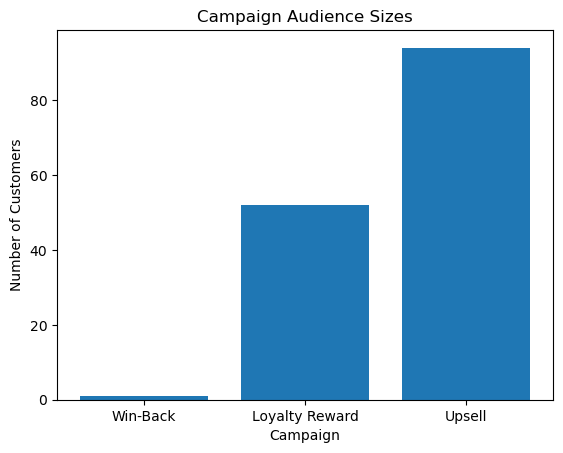


Campaign Summary:
  Win-Back: 1 customers
  Loyalty Reward: 52 customers
  Upsell: 94 customers


In [209]:
# # --------------------------
# # Summary: Campaign Audience Sizes
# # --------------------------
campaigns = {
    'Win-Back': len(winback),
    'Loyalty Reward': len(loyalty),
    'Upsell': len(upsell)
}

plt.figure()
plt.bar(campaigns.keys(), campaigns.values())
plt.title("Campaign Audience Sizes")
plt.xlabel("Campaign")
plt.ylabel("Number of Customers")
plt.show()

print("\nCampaign Summary:")
for name, count in campaigns.items():
    print(f"  {name}: {count} customers")